Mall Customers Clustering Analysis

Installing the Libraries

In [1]:
# for basic mathematics operation 
import numpy as np
import pandas as pd
from pandas import plotting

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# for interactive visualizations
import plotly.offline as py
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go
from plotly import tools
init_notebook_mode(connected = True)
import plotly.figure_factory as ff


Reading the Dataset

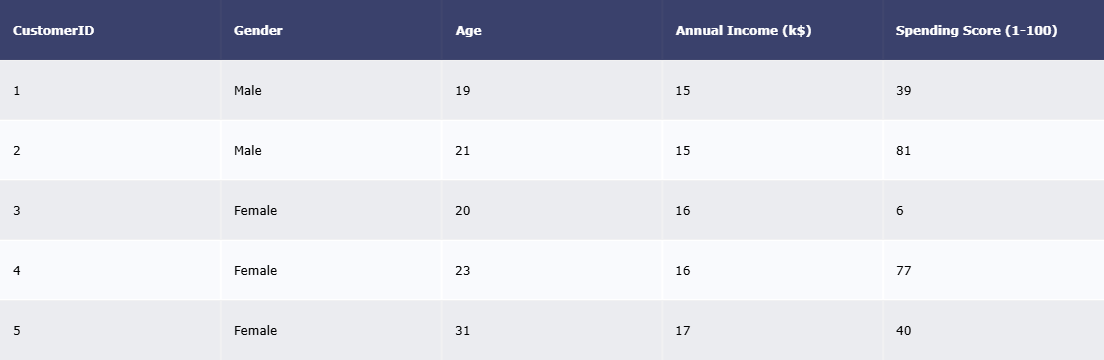

In [2]:
# importing the dataset
data = pd.read_csv(r"C:\Users\Piyush GAJ\Downloads\Mall_Customers.csv")
dat = ff.create_table(data.head())
py.iplot(dat)

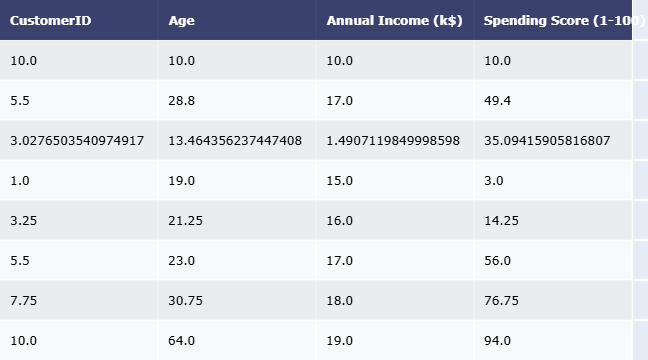

In [3]:
# describing the data
desc = ff.create_table(data.describe())
py.iplot(desc)

In [4]:
# checking if there is NULL data
data.isnull().any().any()

False

Data Visualization

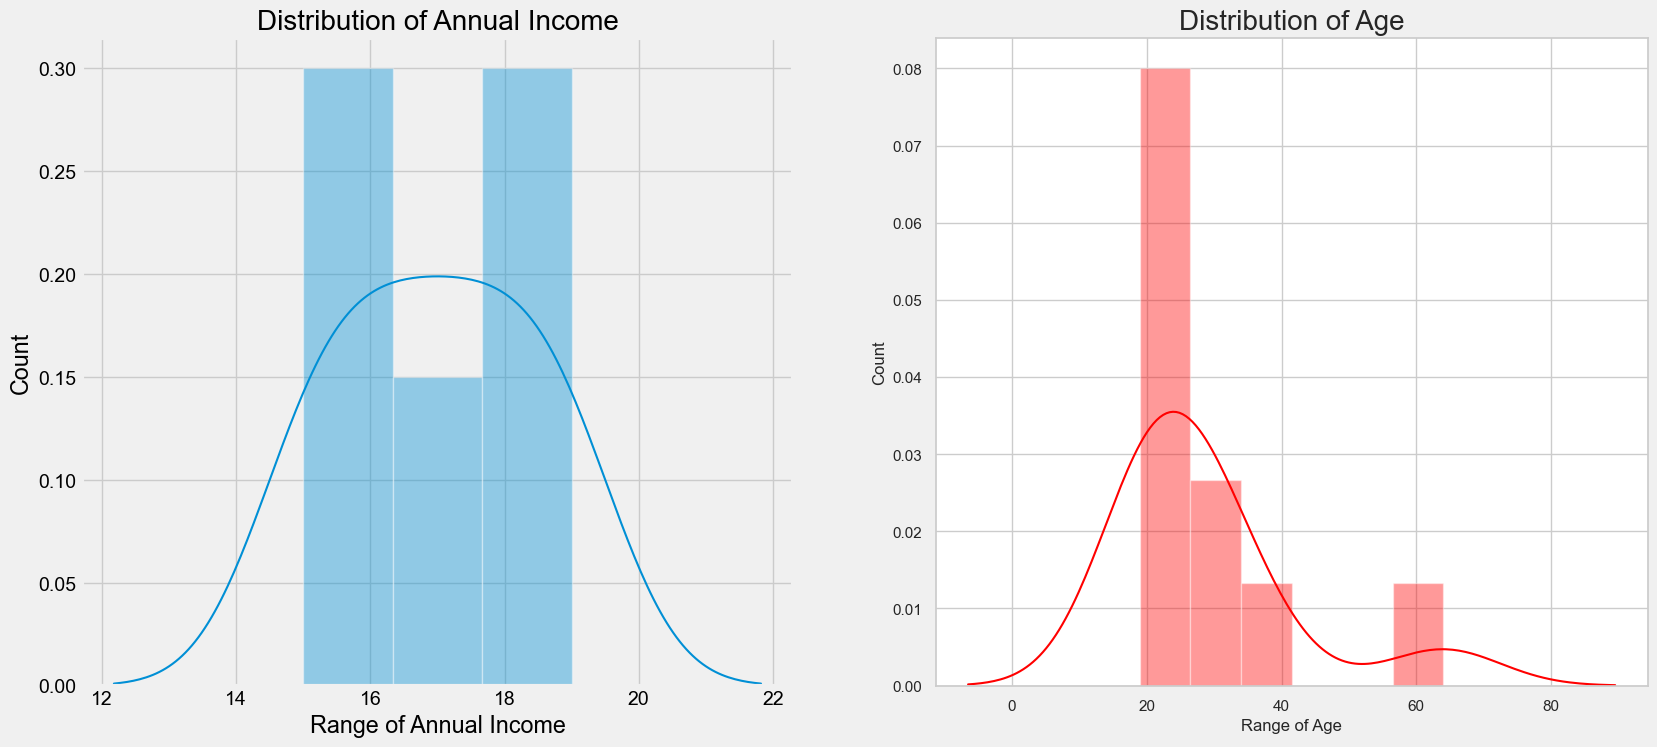

In [5]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (18, 8)

plt.subplot(1, 2, 1)
sns.set(style = 'whitegrid')
sns.distplot(data['Annual Income (k$)'])
plt.title('Distribution of Annual Income', fontsize = 20)
plt.xlabel('Range of Annual Income')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.set(style = 'whitegrid')
sns.distplot(data['Age'], color = 'red')
plt.title('Distribution of Age', fontsize = 20)
plt.xlabel('Range of Age')
plt.ylabel('Count')
plt.show()

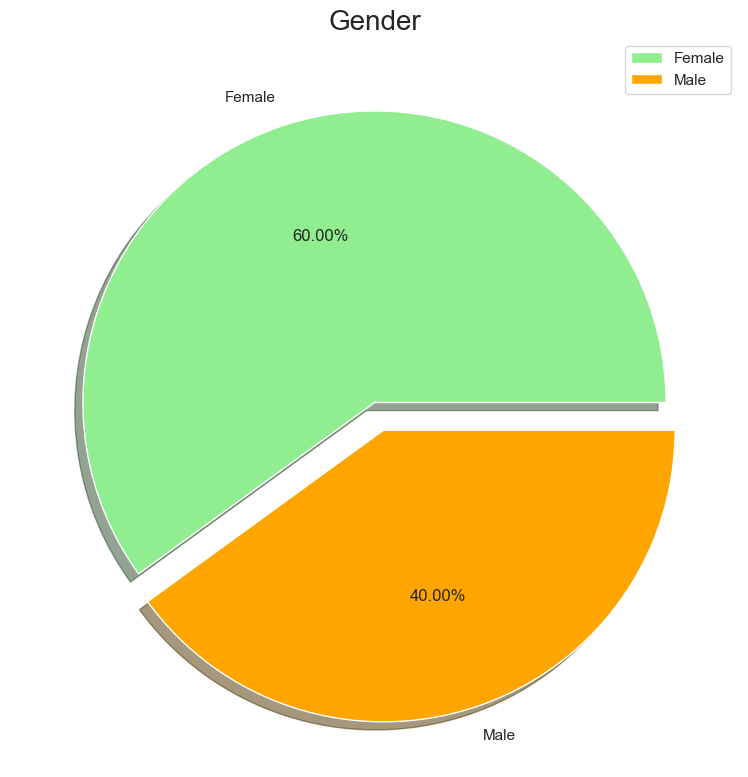

In [6]:
labels = ['Female', 'Male']
size = data['Gender'].value_counts()
colors = ['lightgreen', 'orange']
explode = [0, 0.1]

plt.rcParams['figure.figsize'] = (9, 9)
plt.pie(size, colors = colors, explode = explode, labels = labels, shadow = True, autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')
plt.legend()
plt.show()

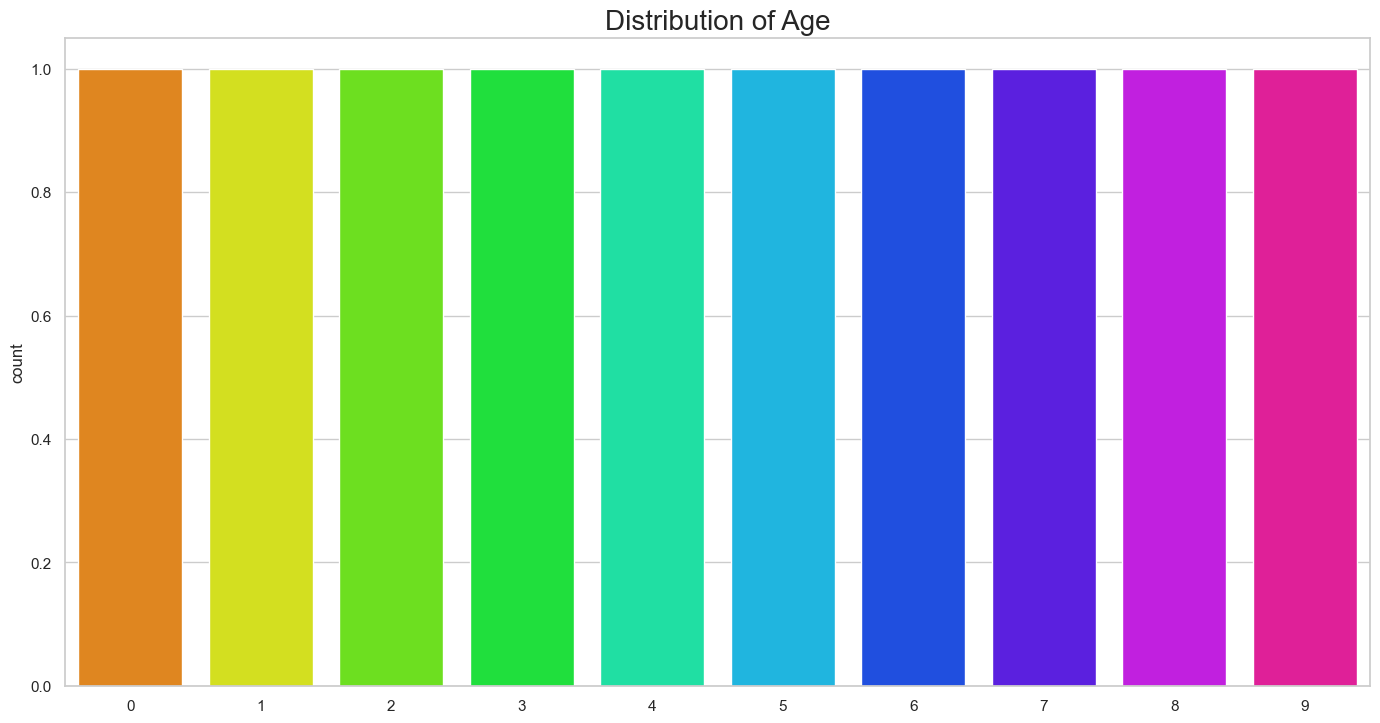

In [7]:
plt.rcParams['figure.figsize'] = (15, 8)
sns.countplot(data['Age'], palette = 'hsv')
plt.title('Distribution of Age', fontsize = 20)
plt.show()

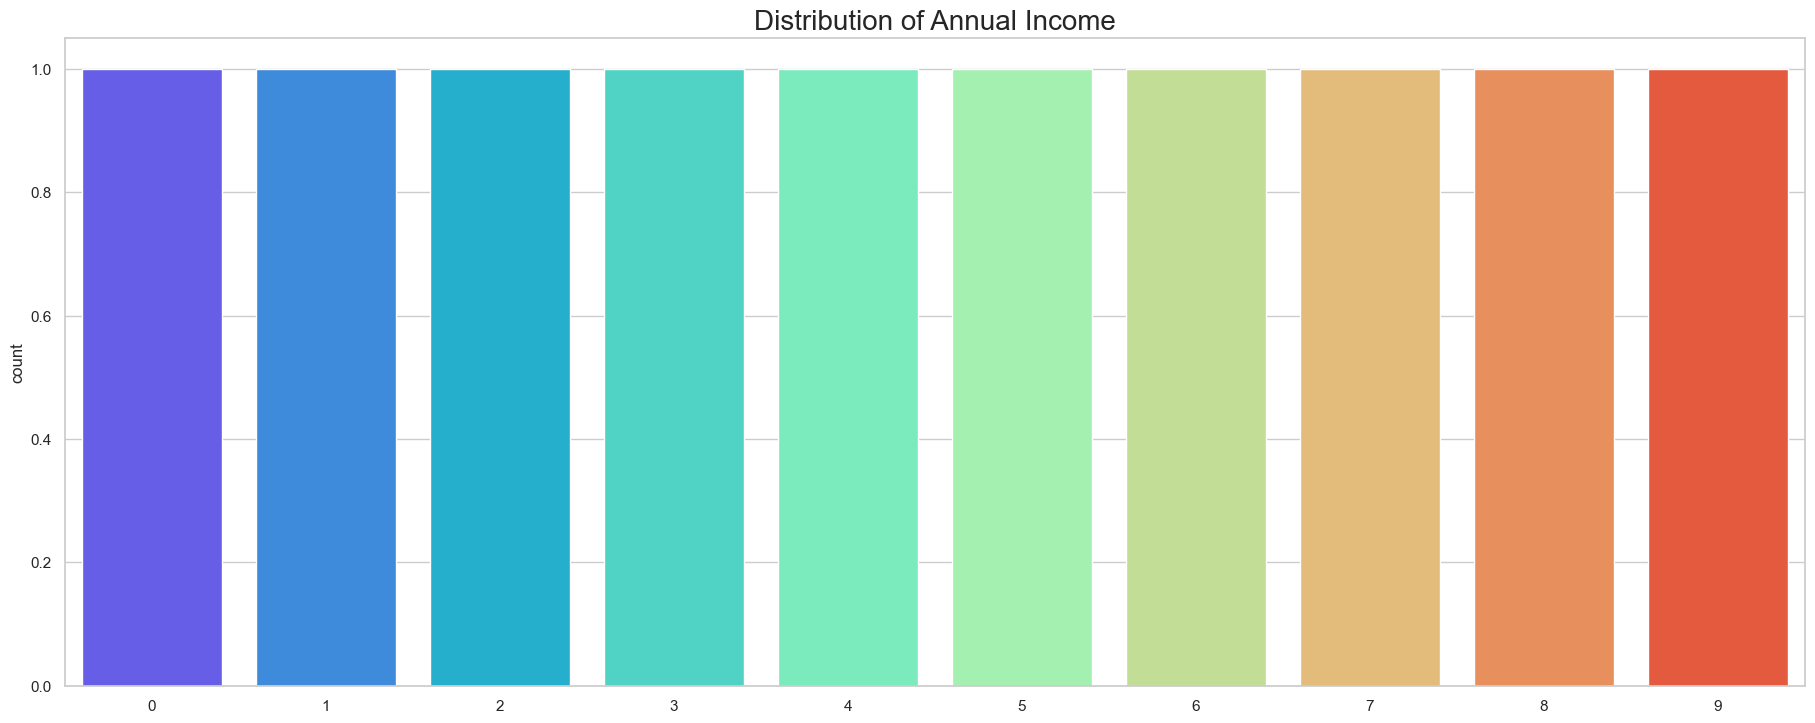

In [8]:
plt.rcParams['figure.figsize'] = (20, 8)
sns.countplot(data['Annual Income (k$)'], palette = 'rainbow')
plt.title('Distribution of Annual Income', fontsize = 20)
plt.show()

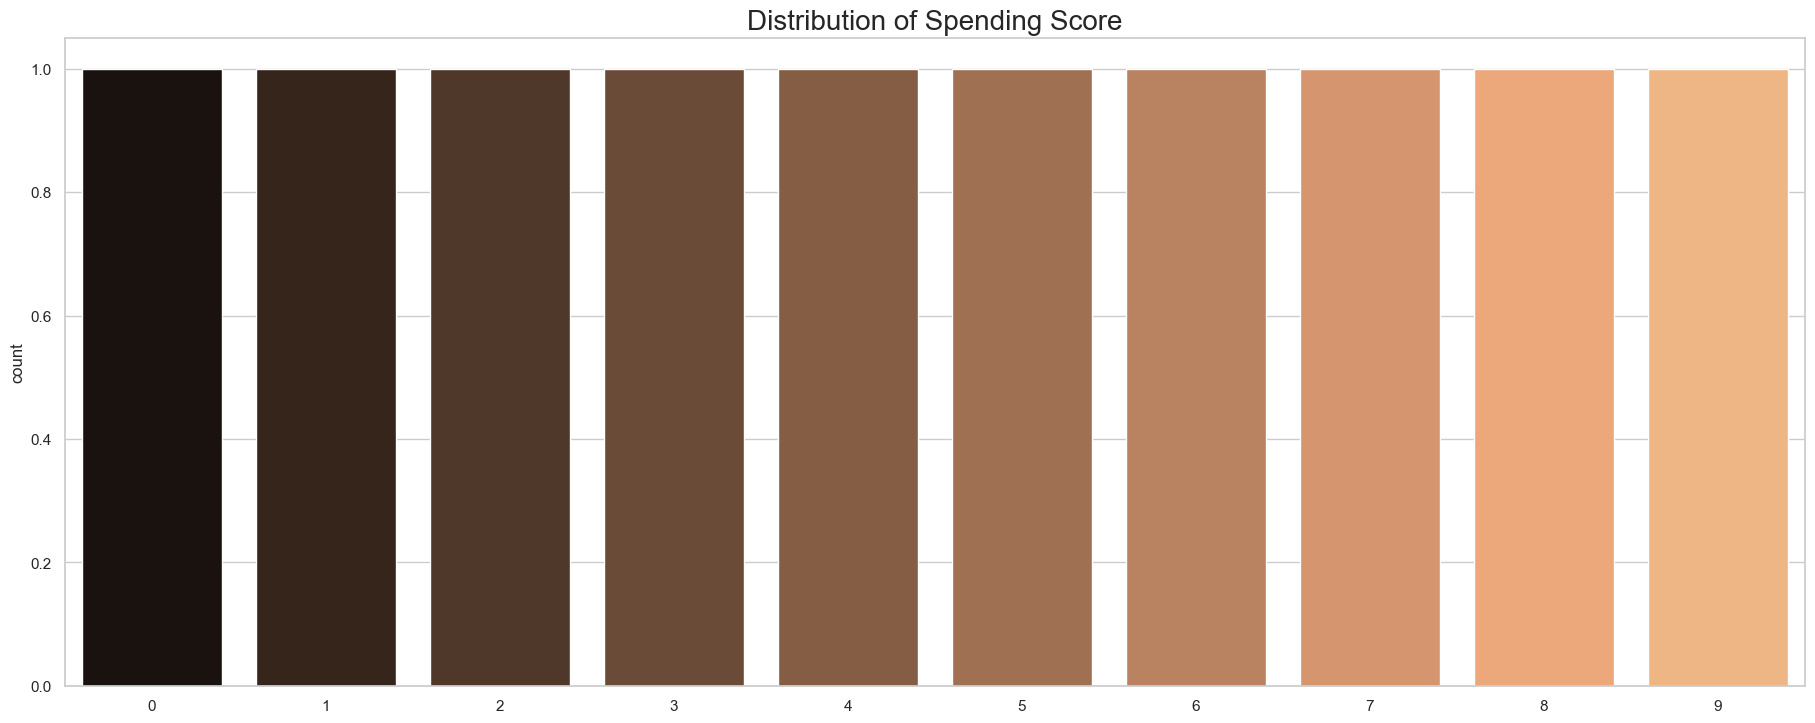

In [10]:
plt.rcParams['figure.figsize'] = (20, 8)
sns.countplot(data['Spending Score (1-100)'], palette = 'copper')
plt.title('Distribution of Spending Score', fontsize = 20)
plt.show()

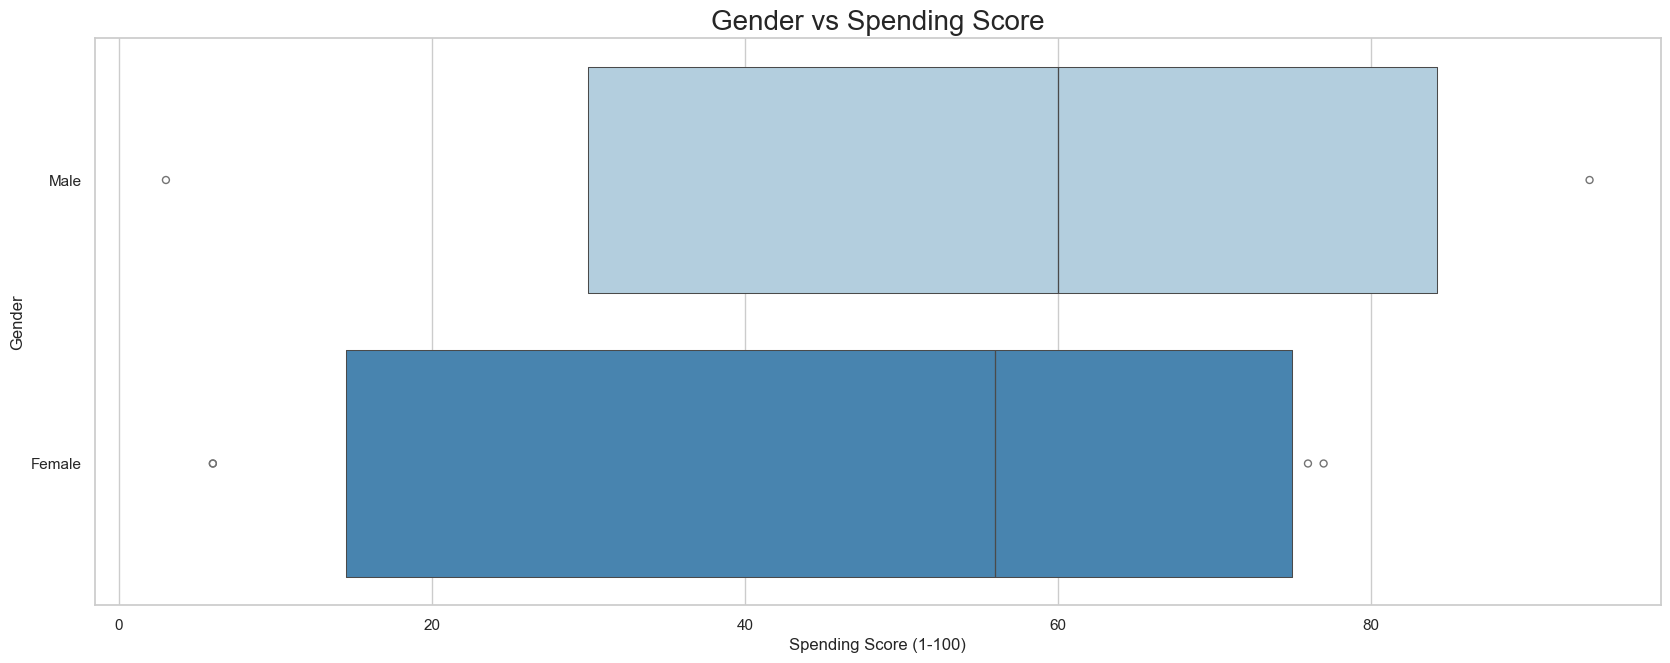

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (18, 7)

sns.boxenplot(
    x='Spending Score (1-100)',
    y='Gender',
    data=data,
    palette='Blues'
)

plt.title('Gender vs Spending Score', fontsize=20)
plt.show()

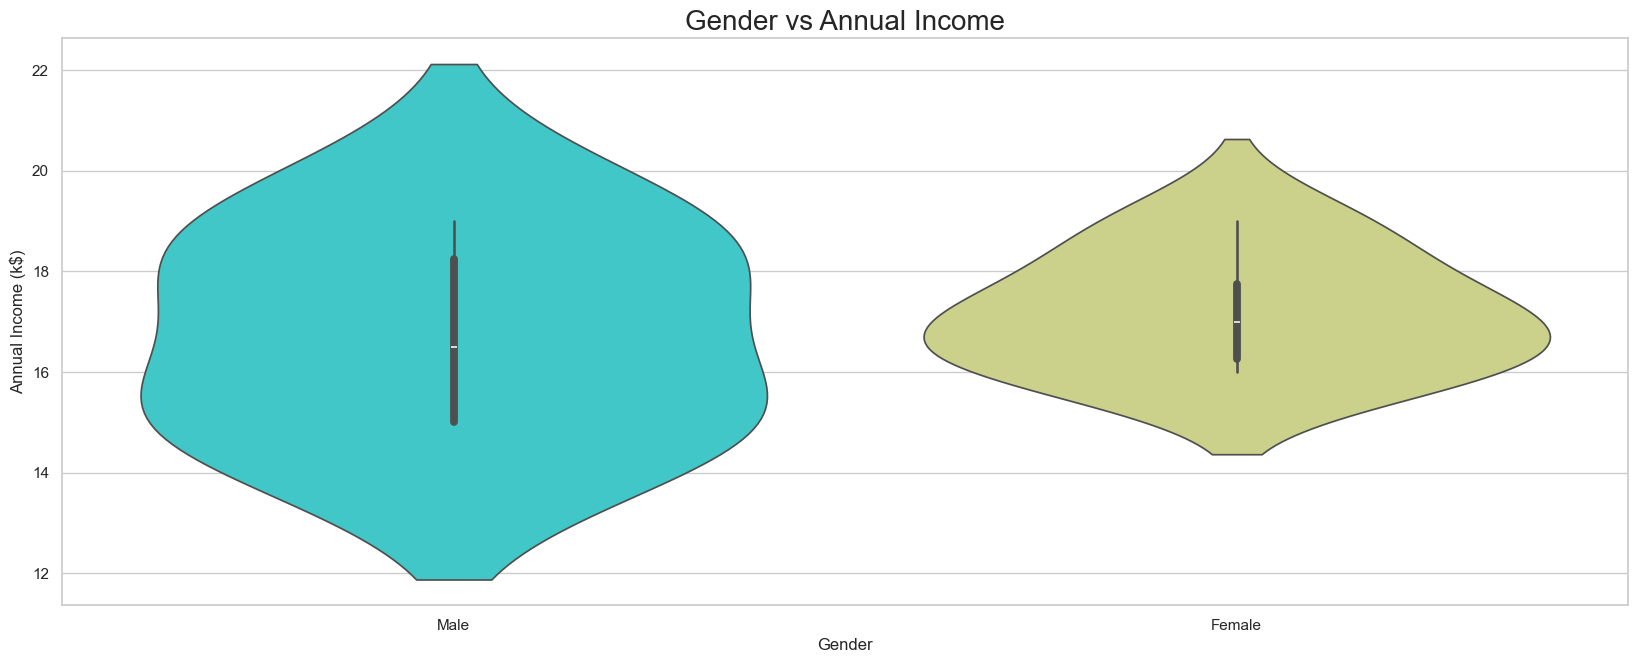

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (18, 7)

sns.violinplot(
    x='Gender',
    y='Annual Income (k$)',
    data=data,
    palette='rainbow'
)

plt.title('Gender vs Annual Income', fontsize=20)
plt.show()

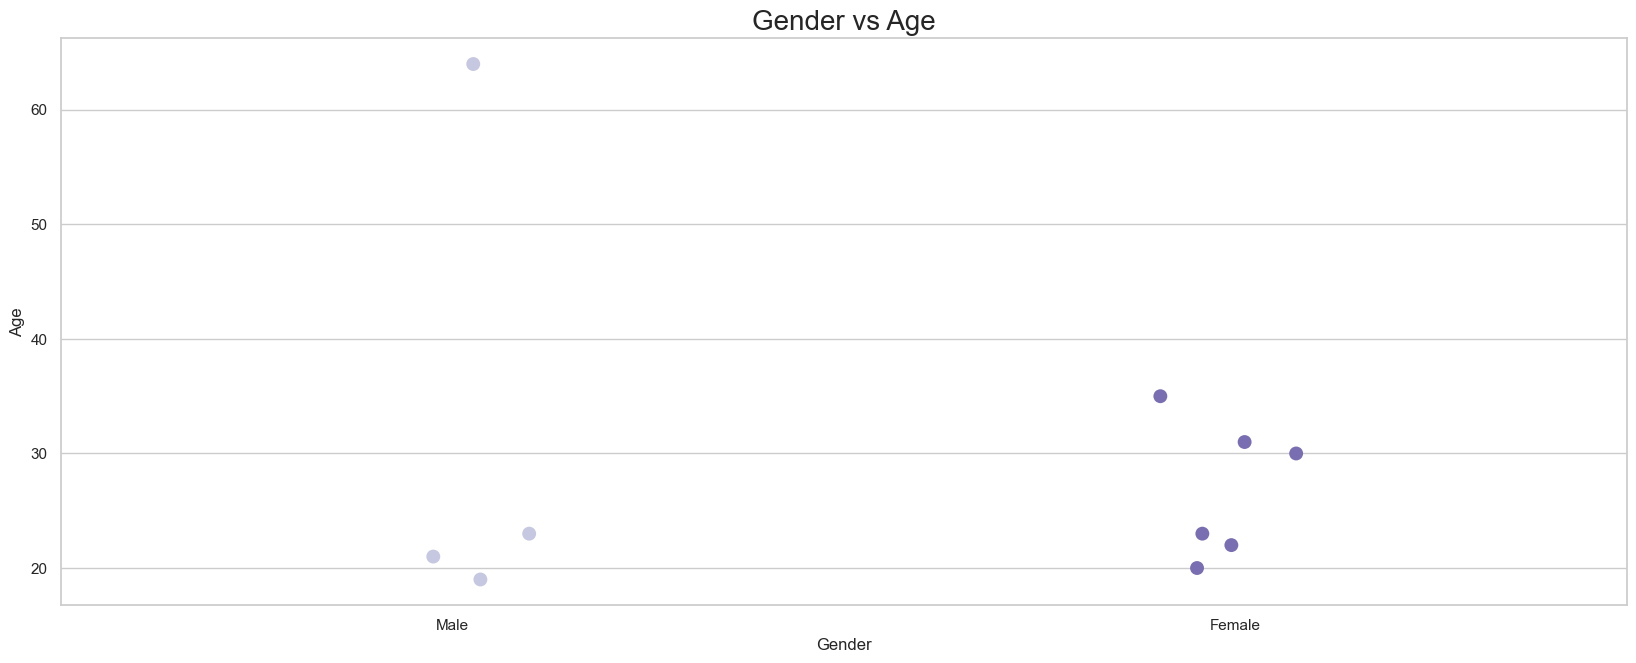

In [26]:
plt.rcParams['figure.figsize'] = (18, 7)
sns.stripplot(
    x='Gender',
    y='Age',
    data=data,
    palette='Purples',
    size=10
)
plt.title('Gender vs Age', fontsize=20)
plt.show()

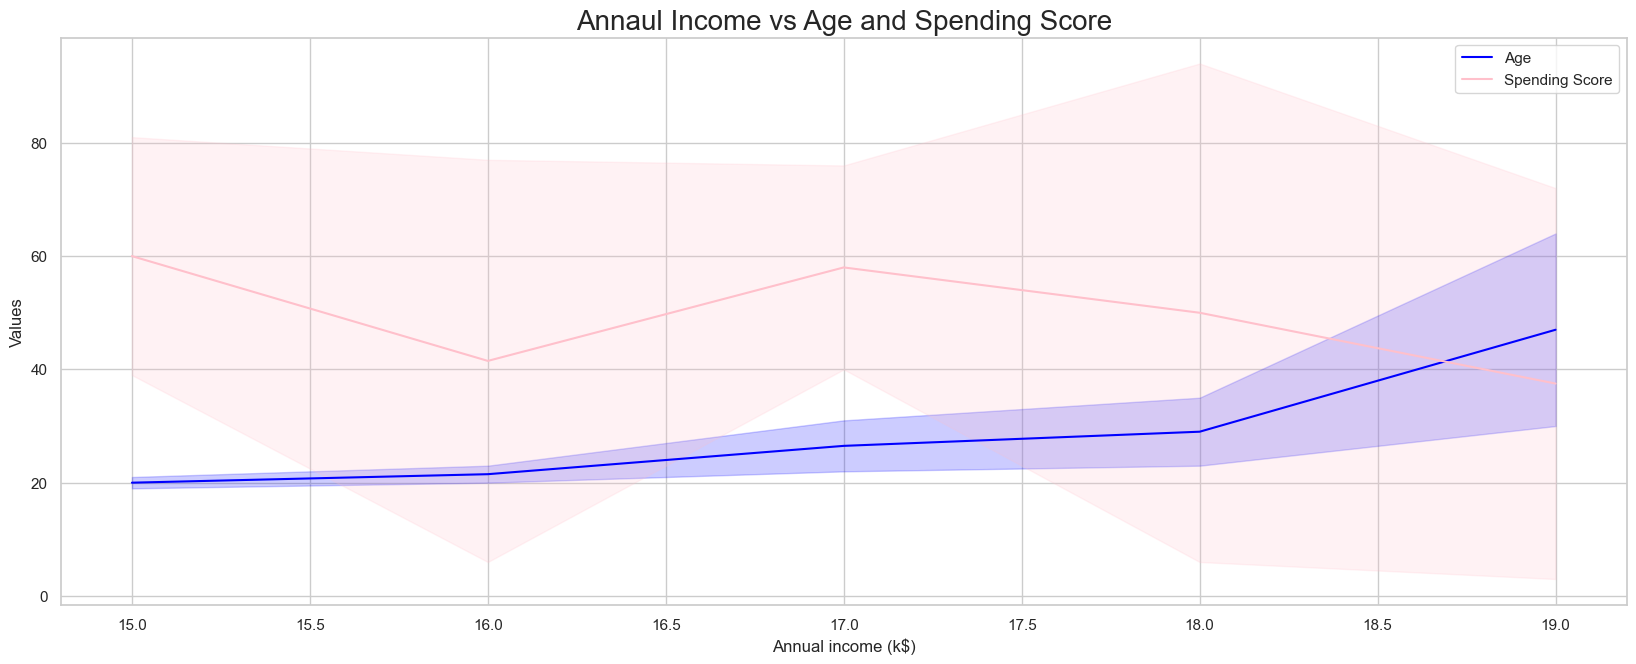

In [29]:
x = data['Annual Income (k$)']
y = data['Age']
z = data['Spending Score (1-100)']

plt.figure(figsize=(18,7))

sns.lineplot(x=x, y=y, color = 'blue', label = 'Age')
sns.lineplot(x=x, y=z, color = 'pink', label = 'Spending Score')

plt.title('Annaul Income vs Age and Spending Score', fontsize = 20)
plt.xlabel('Annual income (k$)')
plt.ylabel('Values')
plt.legend()
plt.show()

Clustering Analysis

In [31]:
x = data.iloc[:, [3, 4]].values

# let's check the shape of x
print(x.shape)

(10, 2)


Kmeans Algorithm

The Elbow Method to find the No. of Optimal Clusters

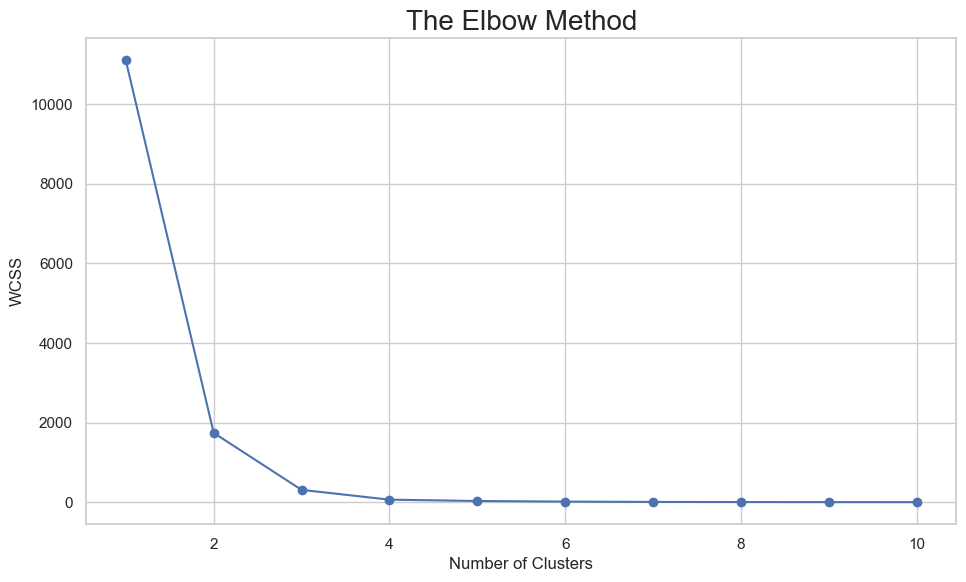

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# selecting features
x = data[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )
    
    km.fit(x)
    wcss.append(km.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method', fontsize=20)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Visulalizaing the Clusters

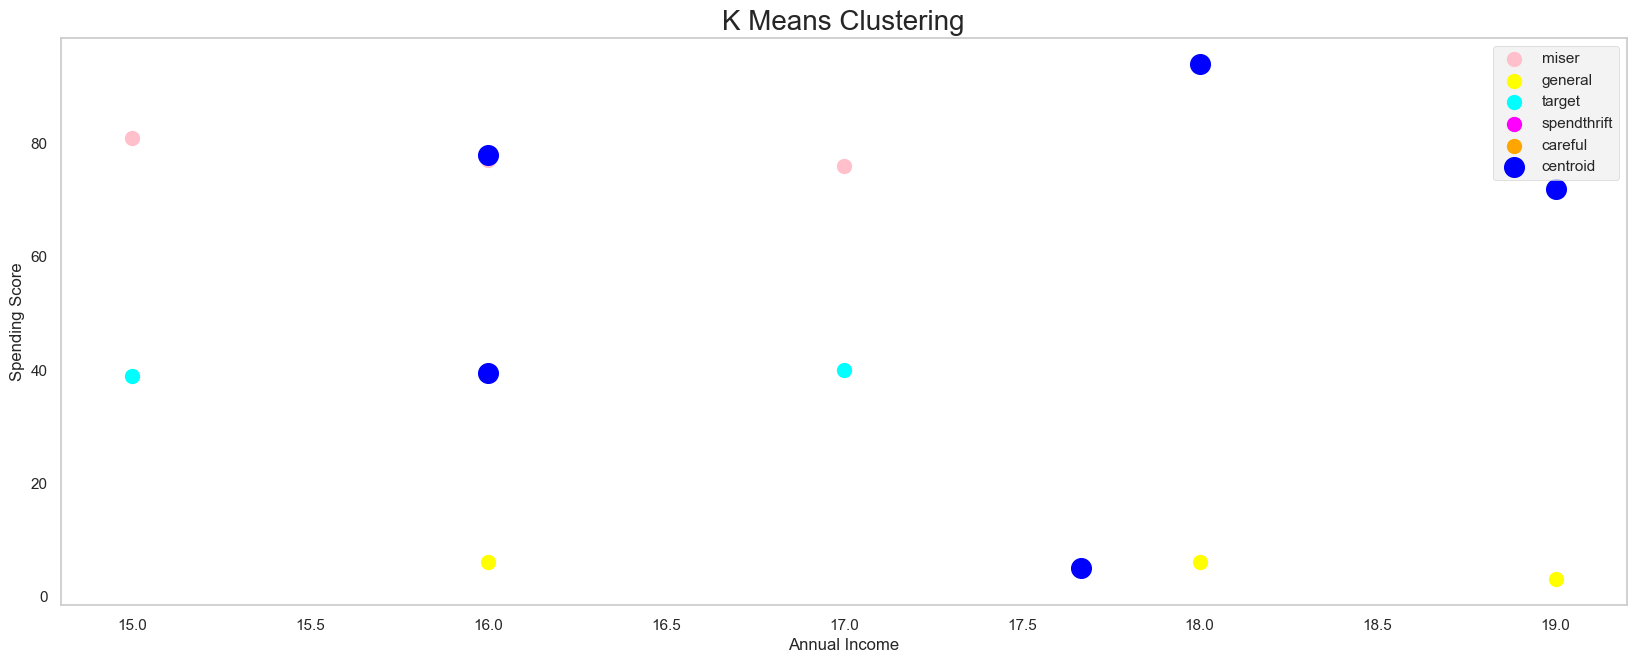

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

x = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

km = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_means = km.fit_predict(x)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, c='pink', label='miser')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, c='yellow', label='general')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, c='cyan', label='target')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, c='magenta', label='spendthrift')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s=100, c='orange', label='careful')

plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], s=200, c='blue', label='centroid')

plt.style.use('fivethirtyeight')
plt.title('K Means Clustering', fontsize=20)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

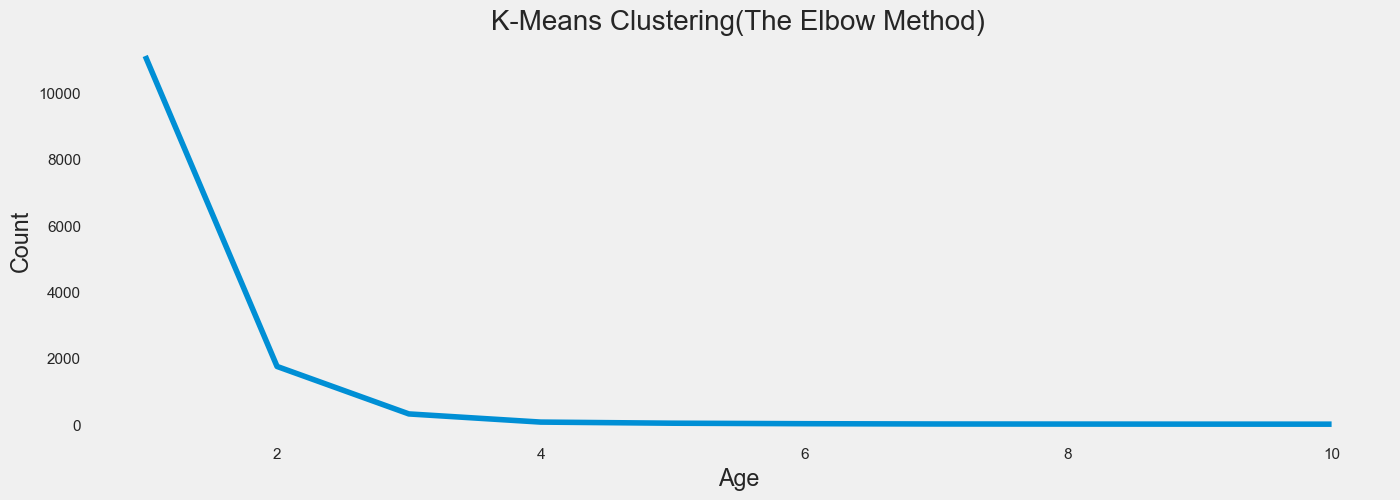

In [41]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.rcParams['figure.figsize'] = (15, 5)
plt.plot(range(1, 11), wcss)
plt.title('K-Means Clustering(The Elbow Method)', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid()
plt.show()

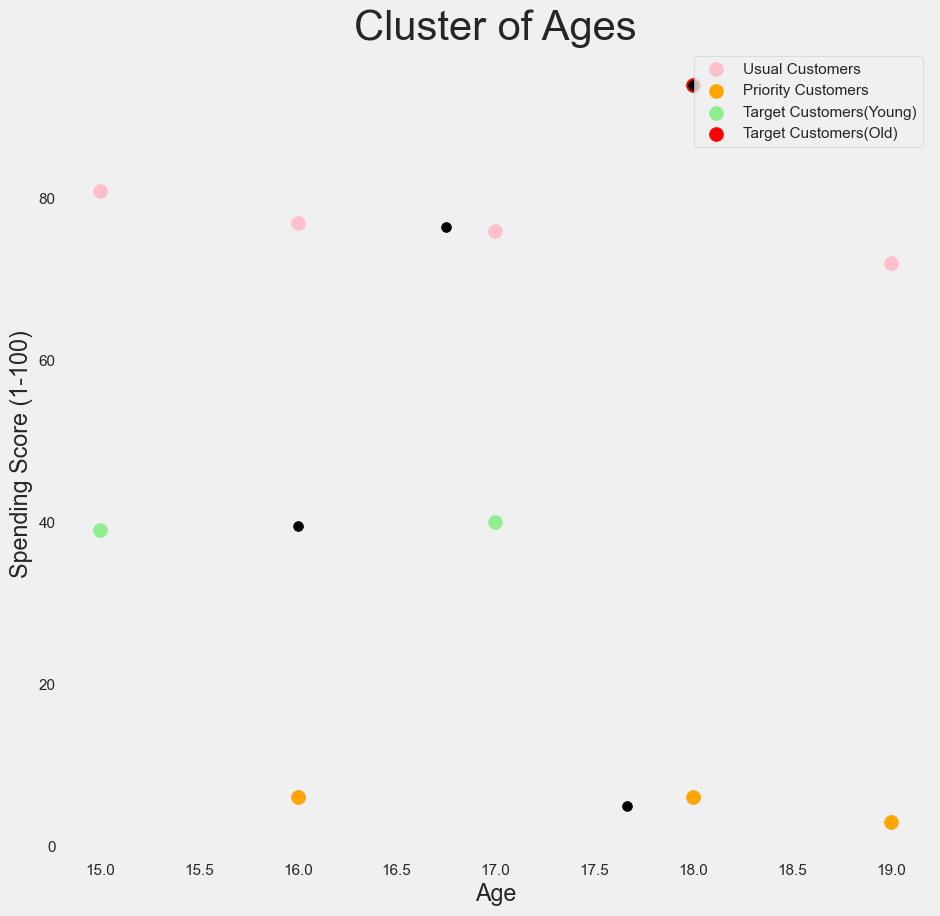

In [47]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
ymeans = kmeans.fit_predict(x)

plt.rcParams['figure.figsize'] = (10, 10)
plt.title('Cluster of Ages', fontsize = 30)

plt.scatter(x[ymeans == 0, 0], x[ymeans == 0, 1], s = 100, c = 'pink', label = 'Usual Customers')
plt.scatter(x[ymeans == 1, 0], x[ymeans == 1, 1], s = 100, c = 'orange', label = 'Priority Customers')
plt.scatter(x[ymeans == 2, 0], x[ymeans == 2, 1], s = 100, c = 'lightgreen', label = 'Target Customers(Young)')
plt.scatter(x[ymeans == 3, 0], x[ymeans == 3, 1], s = 100, c = 'red', label = 'Target Customers(Old)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 50, c = 'black')

plt.style.use('fivethirtyeight')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()

In [48]:
x = data[['Age', 'Spending Score (1-100)', 'Annual Income (k$)']].values
km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
km.fit(x)
labels = km.labels_
centroids = km.cluster_centers_

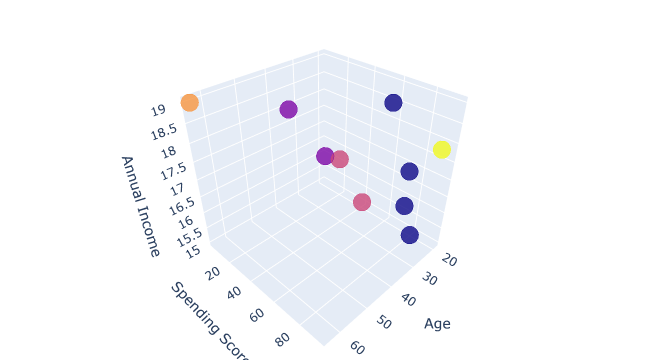

In [50]:
data['labels'] = labels
trace1 = go.Scatter3d(
    x = data['Age'],
    y = data['Spending Score (1-100)'],
    z = data['Annual Income (k$)'],
    mode='markers',
    marker=dict(
        color = data['labels'],
        size= 10,
        line=dict(
            color= data['labels'],
        width= 12
    ),
    opacity=0.8
    )
)
df = [trace1]

layout = go.Layout(
    title = 'Character vs Alive or not',
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=0
    ),
    scene = dict(
        xaxis = dict(title = 'Age'),
        yaxis = dict(title = 'Spending Score'),
        zaxis = dict(title = 'Annual Income')
        )
)

fig = go.Figure(data = df, layout = layout)
py.iplot(fig)